### Setup 
Exercise 1: Import libraries and load a clean test image

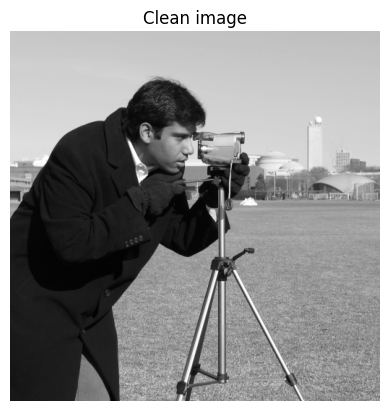

image shape: (512, 512), min: 0.0, max: 1.0, mean intensity: 0.51


In [6]:
import numpy as np 
import matplotlib.pyplot as plt 
 
from skimage import data, util, exposure 
from scipy.ndimage import uniform_filter, median_filter 
img = data.camera().astype(np.float32) / 255.0 # to make it range between 0,1
 
plt.imshow(img, cmap="gray") 
plt.title("Clean image") 
plt.axis("off") 
plt.show() 

# Task 
# 1. Print the image shape, min, max, and mean intensity. 
print(f"image shape: {img.shape}, min: {img.min()}, max: {img.max()}, mean intensity: {img.mean():.2f}")

### 1. Degradation model 
Exercise 1.1: Simulate additive noise and verify the model (code)

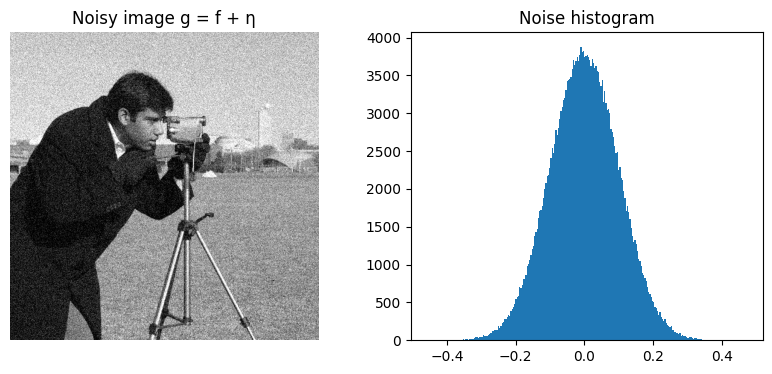

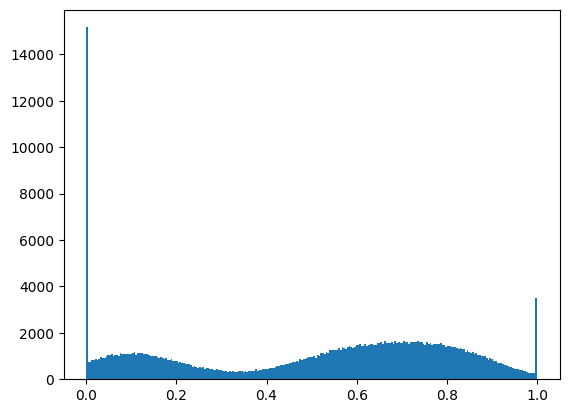

In [ ]:
rng = np.random.default_rng(0) 
 
sigma = 0.1 # u can change it, i made it 0.1 and the mse went to 0.009

noise = rng.normal(0, sigma, img.shape).astype(np.float32) 
g = np.clip(img + noise, 0, 1) 
 
plt.figure(figsize=(10,4)) 
plt.subplot(1,2,1) 
plt.imshow(g, cmap="gray") 
plt.title("Noisy image g = f + η") 
plt.axis("off") 
 
plt.subplot(1,2,2) 
plt.hist(noise.flatten(), bins=256) # this is the array of the noise (just the noise)
plt.title("Noise histogram") 
plt.show()

plt.hist(g.flatten(), bins=256) # this is the image with the noise added
plt.show()

# Tasks 
# 1. Compute the residual g - img and verify it matches the generated noise distribution. 
# 2. Explain why additive noise is a reasonable model for many sensors. 

### 2. Gaussian noise 
Exercise 2.1: Quantify the effect of Gaussian noise (code) 

MSE (clean vs noisy): 0.009061243385076523


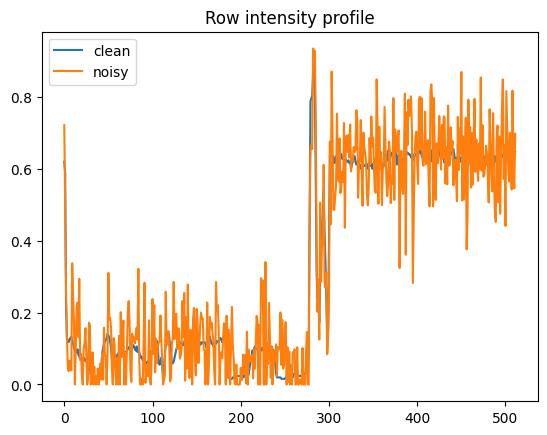

In [18]:
def mse(a, b): 
    a = a.astype(np.float32) 
    b = b.astype(np.float32) 
    return float(np.mean((a - b) ** 2)) 
 
mse_noisy = mse(img, g) 
print("MSE (clean vs noisy):", mse_noisy) 

# Tasks 
# 1. Increase sigma and report how MSE changes. 
# 2. Plot the noisy image row profile and compare with the clean profile. 

# Starter: 
r = img.shape[0] // 2 # take the middle row
plt.plot(img[r, :], label="clean") 
plt.plot(g[r, :], label="noisy") 
plt.title("Row intensity profile") 
plt.legend() 
plt.show() 

### 3. Impulse (salt and pepper) noise 
Exercise 3.1: Add salt and pepper noise and measure corruption level 
(code) 

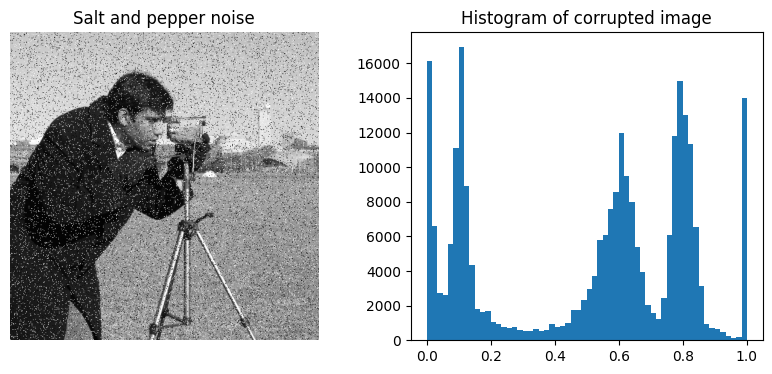

In [ ]:
sp = util.random_noise(img, mode="s&p", amount=0.1).astype(np.float32)
plt.figure(figsize=(10,4)) 
plt.subplot(1,2,1) 
plt.imshow(sp, cmap="gray") 
plt.title("Salt and pepper noise") 
plt.axis("off") 
 
plt.subplot(1,2,2) 
plt.hist(sp.flatten(), bins=60) 
plt.title("Histogram of corrupted image") 
plt.show() 

# Tasks 
# 1. Estimate the percentage of pixels at 0 and at 1 in sp. 
# number of pixels with intensity 0 / all pixels, same as one
# 2. Compare this with the amount parameter you used. 

### 4. Mean filtering for Gaussian noise 
Exercise 4.1: Mean filter and blur trade off (code)

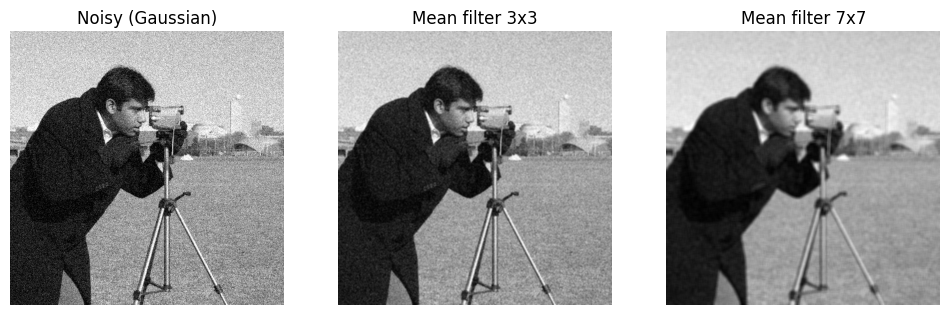

MSE noisy: 0.009061243385076523
MSE mean3: 0.002221661387011409
MSE mean7: 0.0033750133588910103


In [ ]:
mean3 = uniform_filter(g, size=3) # the same as the mean filter
mean7 = uniform_filter(g, size=7) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(g, cmap="gray") 
plt.title("Noisy (Gaussian)") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(mean3, cmap="gray") 
plt.title("Mean filter 3x3") 
plt.axis("off") 
 
plt.subplot(1,3,3) 
plt.imshow(mean7, cmap="gray") 
plt.title("Mean filter 7x7") 
plt.axis("off") 
plt.show() 
 
print("MSE noisy:", mse(img, g)) 
print("MSE mean3:", mse(img, mean3)) 
print("MSE mean7:", mse(img, mean7)) 

# Questions 
# 1. Which window size gives lower MSE?  window of 3
# 2. Which window size causes more edge blur, and why? window 7, it is bigger and takes the mean of 
# 49 pixel all together making it blur

### 5. Geometric mean filtering 
Exercise 5.1: Implement a geometric mean filter (code) 

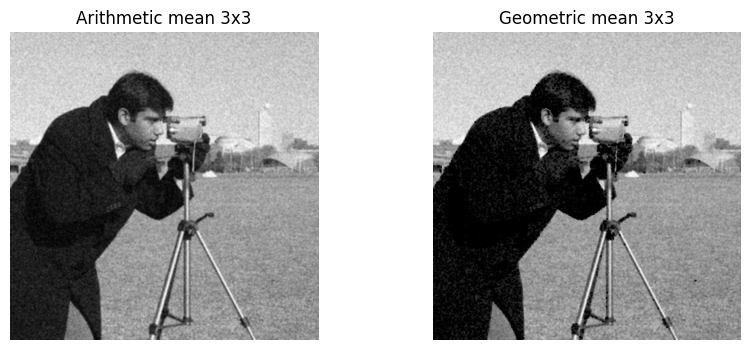

MSE geo3: 0.003962727263569832
MSE mean3: 0.002221661387011409


In [ ]:
def geometric_mean_filter(im, size=3, eps=1e-6): 
    # log-domain to avoid underflow 
    im2 = np.clip(im, eps, 1.0) 
    log_im = np.log(im2) 
    m = uniform_filter(log_im, size=size) 
    return np.exp(m) # because of the sigma of ln times the 1/mn so this makes it mean of the ln of pixels in the filter, so we take the exp so ln can go, remember the range in the image is 0,1
 
geo3 = geometric_mean_filter(g, size=3) 
 
plt.figure(figsize=(10,4)) 
plt.subplot(1,2,1) 
plt.imshow(mean3, cmap="gray") 
plt.title("Arithmetic mean 3x3") 
plt.axis("off") 
 
plt.subplot(1,2,2) 
plt.imshow(geo3, cmap="gray") 
plt.title("Geometric mean 3x3") 
plt.axis("off") 
plt.show() 
 
print("MSE geo3:", mse(img, geo3)) 

# Tasks 
# 1. Show what happens if eps is set to 0 and explain the failure. 
# the result is a little bit scary, it is like someone bites the image, 
# 2. Compare geometric mean with arithmetic mean using MSE and edge appearance. 
print("MSE mean3:", mse(img, mean3))

### 6. Contraharmonic mean filter 
Exercise 6.1: Implement contraharmonic filter and test salt vs pepper 
removal (code) 


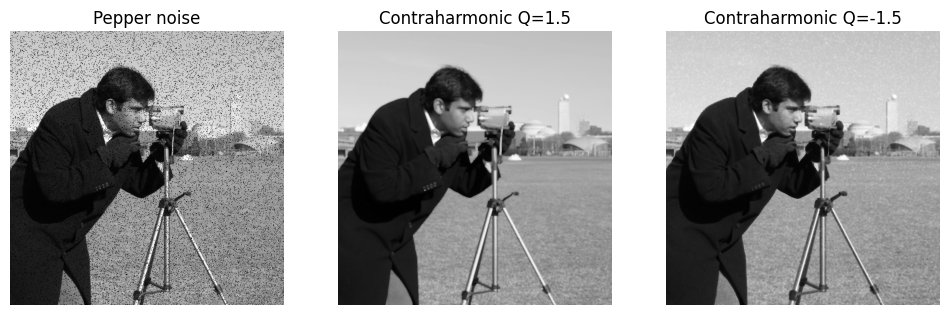

In [33]:
from scipy.ndimage import generic_filter 
 
def contraharmonic(im, size=3, Q=1.5, eps=1e-6): 
    def f(window): 
        w = np.array(window, dtype=np.float32) 
        num = np.sum((w + eps) ** (Q + 1)) 
        den = np.sum((w + eps) ** Q) 
        return num / (den + eps) 
    return generic_filter(im, f, size=size) 
 
# Create separate salt-heavy and pepper-heavy examples 
sp_more_salt = util.random_noise(img, mode="salt", 
amount=0.08).astype(np.float32) 
sp_more_pepper = util.random_noise(img, mode="pepper", 
amount=0.08).astype(np.float32) 
 
Q_pos = 1.5   # should reduce pepper 
Q_neg = -1.5  # should reduce salt 
 
pepper_fixed = contraharmonic(sp_more_pepper, size=3, Q=Q_pos) 
salt_fixed = contraharmonic(sp_more_salt, size=3, Q=Q_neg) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(sp_more_pepper, cmap="gray") 
plt.title("Pepper noise") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(pepper_fixed, cmap="gray") 
plt.title(f"Contraharmonic Q={Q_pos}") 
plt.axis("off") 
 
plt.subplot(1,3,3) 
plt.imshow(salt_fixed, cmap="gray") 
plt.title(f"Contraharmonic Q={Q_neg}") 
plt.axis("off") 
plt.show() 

# Questions 
# 1. Why does positive Q suppress pepper noise? 
# 2. Why does negative Q suppress salt noise? 
# 3. What visual artefact appears if Q is chosen incorrectly?

### 7. Median filter for impulse noise 
Exercise 7.1: Median filter and repeated application (code) 

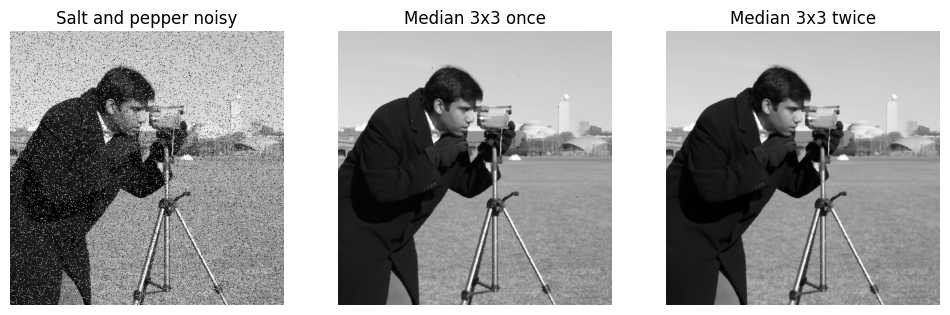

MSE noisy: 0.033618178218603134
MSE med once: 0.0011188257485628128
MSE med twice: 0.0011034936178475618


In [ ]:
med3 = median_filter(sp, size=3) 
med3_twice = median_filter(med3, size=3) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(sp, cmap="gray") 
plt.title("Salt and pepper noisy") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(med3, cmap="gray")  
plt.title("Median 3x3 once") 
plt.axis("off") 
 
plt.subplot(1,3,3) 
plt.imshow(med3_twice, cmap="gray") 
plt.title("Median 3x3 twice") 
plt.axis("off") 
plt.show() 
 
print("MSE noisy:", mse(img, sp)) 
print("MSE med once:", mse(img, med3)) 
print("MSE med twice:", mse(img, med3_twice)) 

# Tasks 
# 1. Explain why median filtering works well for salt and pepper noise.
# avoid choosing the extreme values at min and max
# 2. Explain why repeated median filtering can distort fine details. 

### 8. Min, max, and midpoint filters 
Exercise 8.1: Implement min, max, and midpoint filtering (code) 

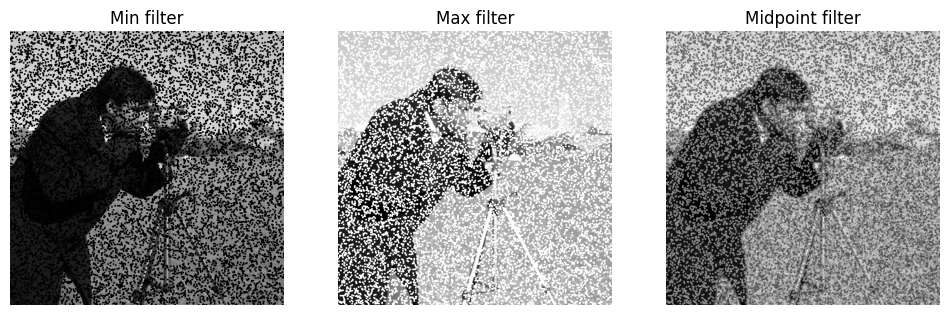

In [31]:
from scipy.ndimage import minimum_filter, maximum_filter 
 
minf = minimum_filter(sp, size=3) 
maxf = maximum_filter(sp, size=3) 
mid = 0.5 * (minf + maxf) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(minf, cmap="gray") 
plt.title("Min filter") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(maxf, cmap="gray") 
plt.title("Max filter") 
plt.axis("off") 
 
plt.subplot(1,3,3) 
plt.imshow(mid, cmap="gray") 
plt.title("Midpoint filter") 
plt.axis("off") 
plt.show() 

# Questions 
# 1. Which filter suppresses salt noise more, and why? 
# 2. Which filter suppresses pepper noise more, and why? 
# 3. Why does midpoint filtering fail for impulse noise? 